In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
data = pd.read_csv('../data/recon_timeseries.csv', header=0)

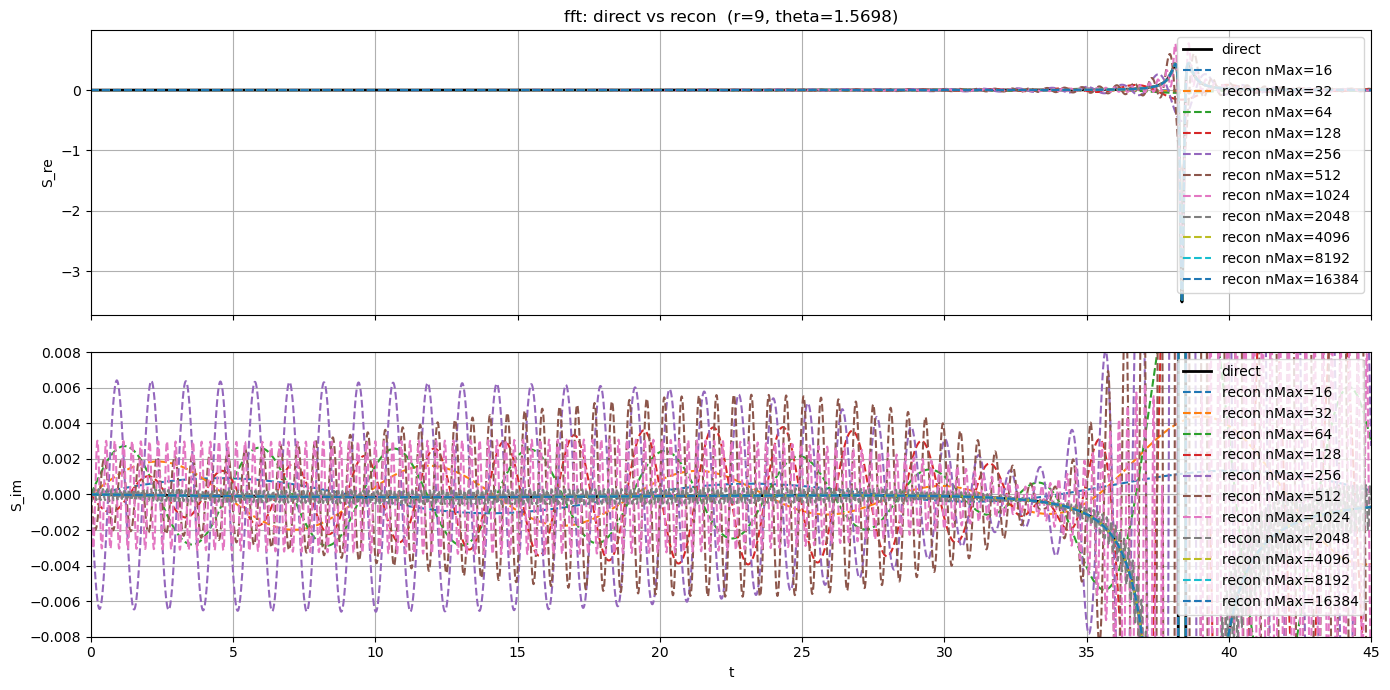

In [49]:
# direct (original source) vs n-mode reconstruction, fft method
fft = data[data.method == 'fft']

# one field point per plot; take the first if the grid has several
rF, th = fft.rField.iloc[0], fft.theta.iloc[0]
fft = fft[(fft.rField == rF) & (fft.theta == th)]

nmaxes = sorted(fft.nMax.unique())
# direct_* is identical across nMax; grab any (largest) for the reference curve
direct = fft[fft.nMax == nmaxes[-1]].sort_values('t')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, comp in zip(axes, ['re', 'im']):
    ax.plot(direct.t, direct[f'direct_{comp}'], 'k-', lw=2, label='direct')
    for nMax in nmaxes:
        sub = fft[fft.nMax == nMax].sort_values('t')
        ax.plot(sub.t, sub[f'recon_{comp}'], '--', label=f'recon nMax={nMax}')
    ax.set_ylabel(f'S_{comp}')
    ax.grid(True)
    ax.legend()
axes[1].set_xlabel('t')
axes[0].set_title(f'fft: direct vs recon  (r={rF:g}, theta={th:g})')
plt.xlim(0,45)
plt.ylim(-0.008,0.008)
plt.tight_layout()
plt.show()

## Adaptive Mino-time stepping & spline-integrand diagnostics

The `minospline` integrator places its nodes on a Mino-time mesh graded toward
closest approach (density ~ 1/dist^1.5). The cells below visualize:

1. **Where the adaptive nodes land** on the source vs a dense uniform-t sampling,
   and the node spacing in coordinate time (dips mark clustering at closest approach).
2. **How well the cubic spline** through the raw (n-independent) source nodes —
   the spline the integrator actually quadratures — reproduces the true
   time-domain source, plus the pointwise interpolation error.

Run `recontest` with `dumpMesh=1` and `dumpSpline=1` to produce
`data/recon_mesh.csv` and `data/recon_spline.csv`.

In [50]:
# diagnostics for the minospline graded mesh (adaptive Mino-time stepping).
# Requires recontest run with dumpMesh=1 and dumpSpline=1.
mesh   = pd.read_csv('../data/recon_mesh.csv',   comment='#')
spline = pd.read_csv('../data/recon_spline.csv', comment='#')

# pick the first field point
rF, th = mesh.rField.iloc[0], mesh.theta.iloc[0]
mesh1   = mesh[(mesh.rField == rF) & (mesh.theta == th)].sort_values('node_i')
spline1 = spline[(spline.rField == rF) & (spline.theta == th)].sort_values('lambda')

# dense "true" time-domain source from the timeseries dump (direct_* is the
# directly-evaluated source, identical across method/nMax)
tru = data[(data.rField == rF) & (data.theta == th)]
tru = tru[tru.nMax == sorted(tru.nMax.unique())[-1]]
tru = tru.drop_duplicates('t').sort_values('t')

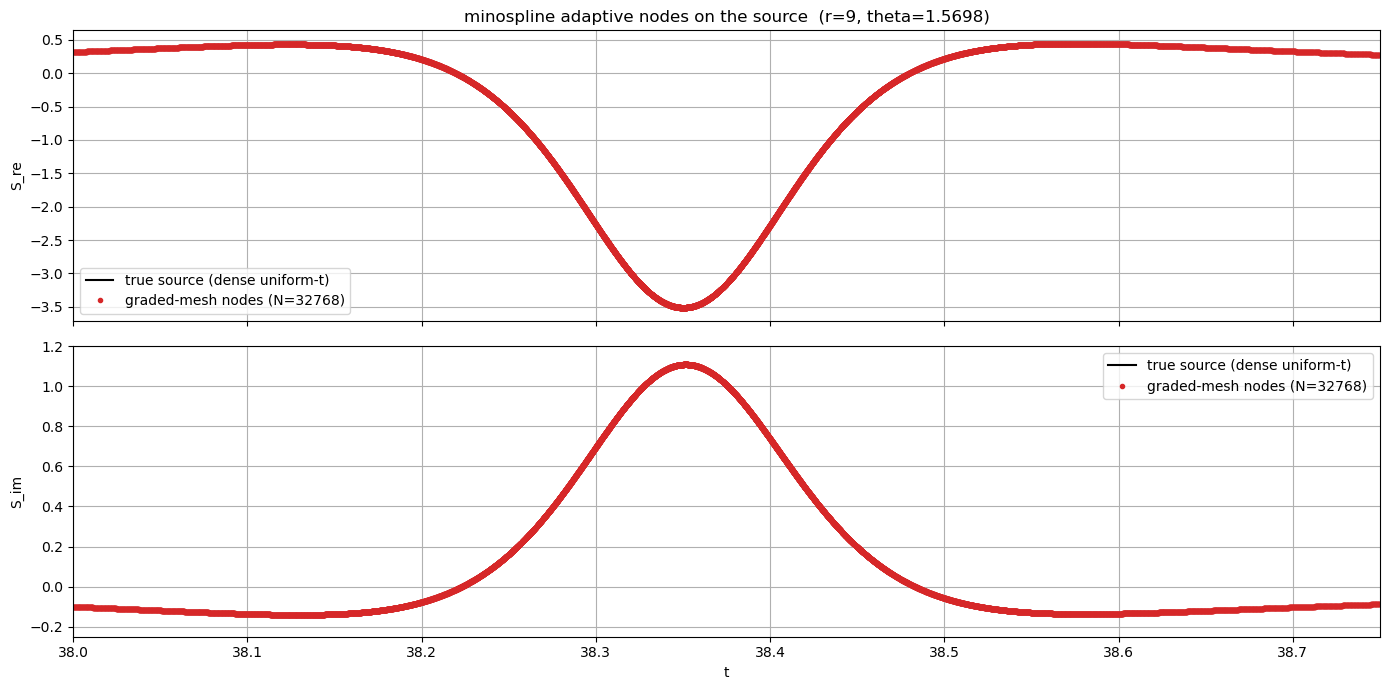

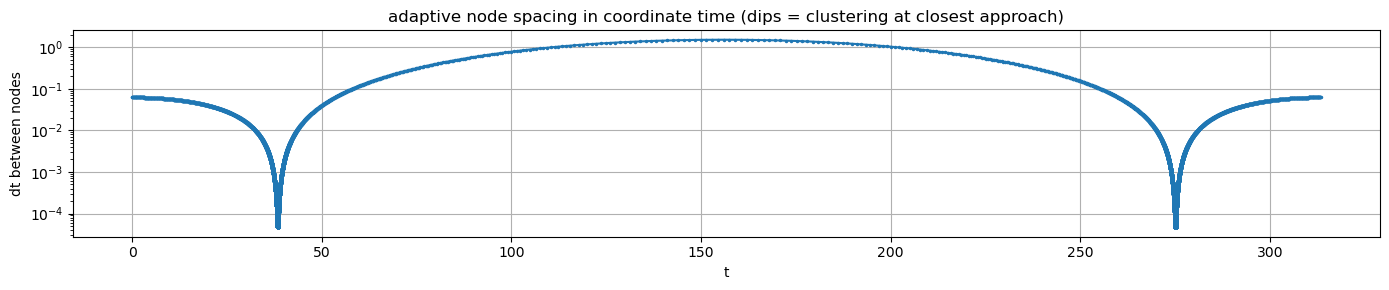

In [51]:
# --- adaptive Mino-time node placement vs dense uniform-t sampling ---
# The graded mesh clusters nodes where the source peaks (closest approach).
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, comp in zip(axes, ['re', 'im']):
    ax.plot(tru.t, tru[f'direct_{comp}'], 'k-', lw=1.5,
            label='true source (dense uniform-t)')
    ax.plot(mesh1.t, mesh1[f'src_{comp}'], 'o', ms=3, color='C3',
            label=f'graded-mesh nodes (N={len(mesh1)})')
    ax.set_ylabel(f'S_{comp}')
    ax.grid(True); ax.legend()
axes[1].set_xlabel('t')
axes[0].set_title(f'minospline adaptive nodes on the source  (r={rF:g}, theta={th:g})')
axes[1].set_ylim(-.25,1.2)
plt.xlim(38,38.75)
plt.tight_layout(); plt.show()

# node density: dt between consecutive nodes vs t (small dt = dense sampling)
plt.figure(figsize=(14, 3))
plt.semilogy(mesh1.t.values[:-1], np.diff(mesh1.t.values), '.-', ms=3)
plt.xlabel('t'); plt.ylabel('dt between nodes'); plt.grid(True)
plt.title('adaptive node spacing in coordinate time (dips = clustering at closest approach)')
plt.tight_layout(); plt.show()

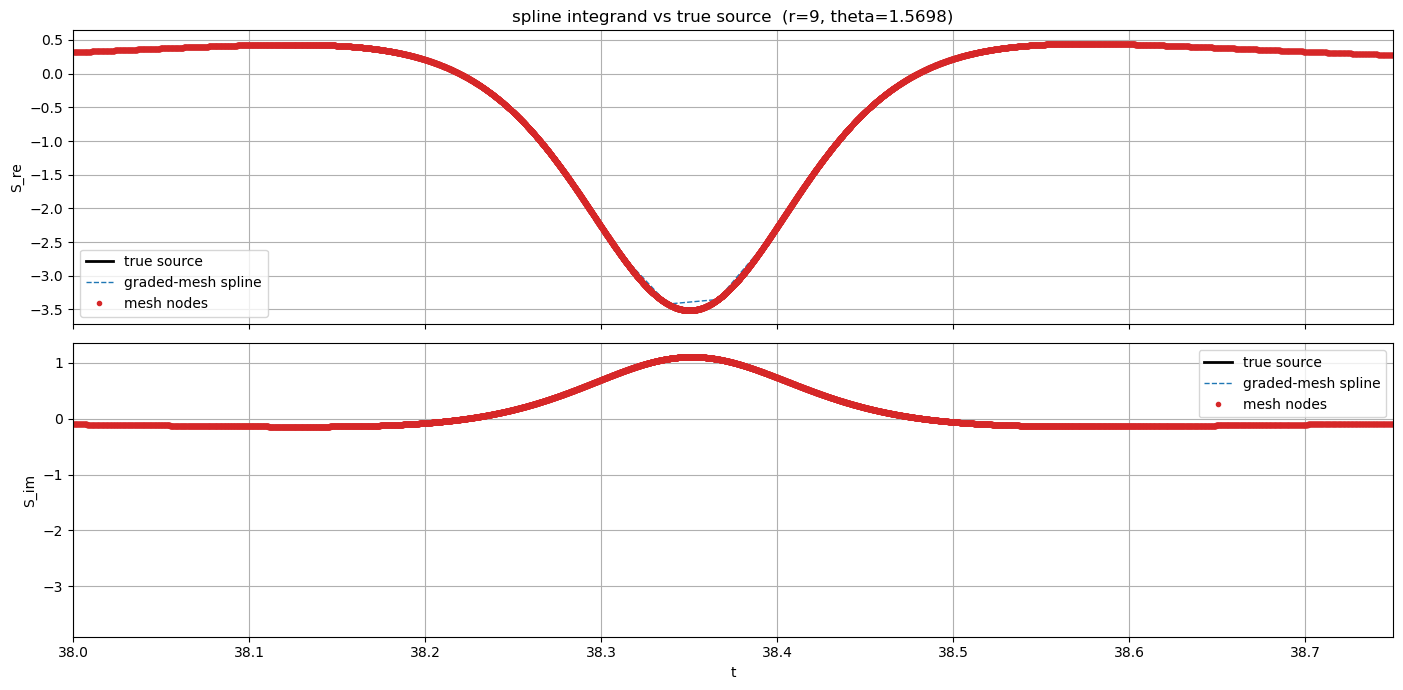

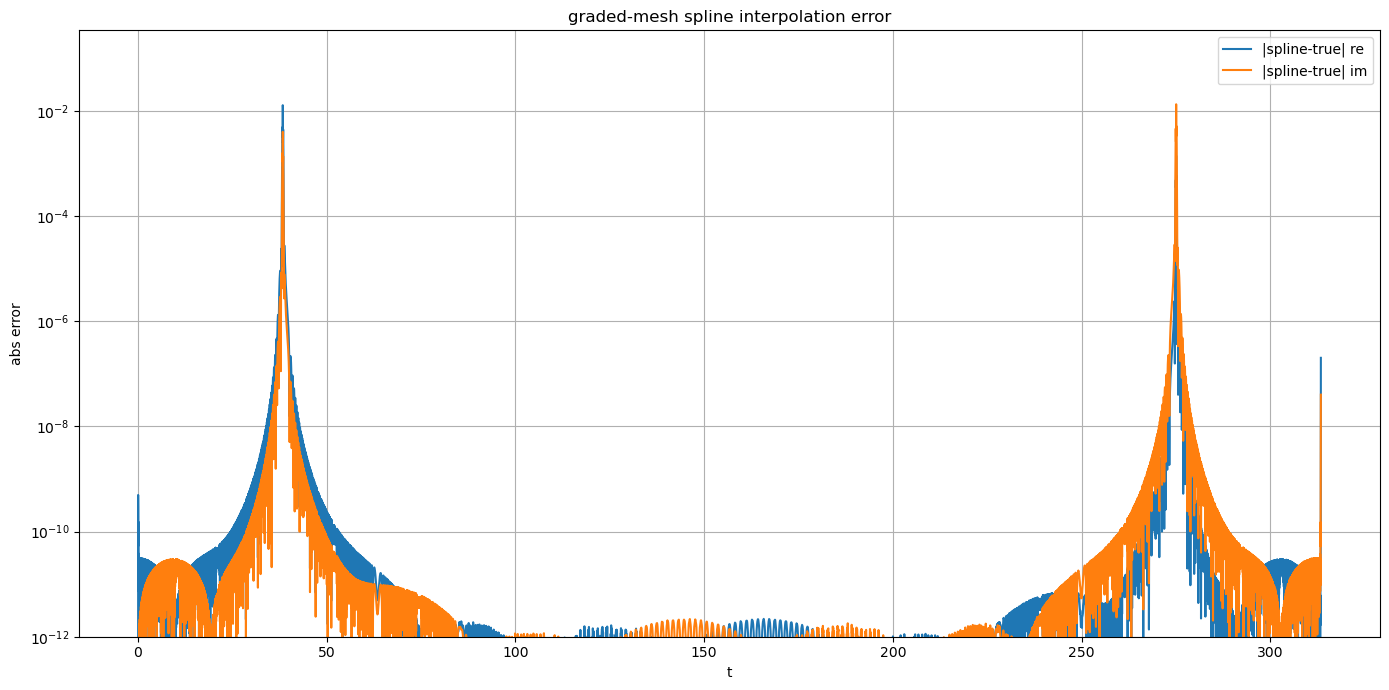

In [52]:
# --- spline integrand interpolant vs true source ---
# Cubic spline built over the graded-mesh raw (n-independent) source nodes,
# evaluated densely. Overlap with the true dense source shows how well the
# spline the integrator integrates actually captures S(t).
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, comp in zip(axes, ['re', 'im']):
    ax.plot(tru.t, tru[f'direct_{comp}'], 'k-', lw=2, label='true source')
    ax.plot(spline1.t, spline1[f'spline_src_{comp}'], '--', color='C0', lw=1,
            label='graded-mesh spline')
    ax.plot(mesh1.t, mesh1[f'src_{comp}'], 'o', ms=3, color='C3', label='mesh nodes')
    ax.set_ylabel(f'S_{comp}')
    ax.grid(True); ax.legend()
axes[1].set_xlabel('t')
axes[0].set_title(f'spline integrand vs true source  (r={rF:g}, theta={th:g})')
plt.xlim(38,38.75)
plt.tight_layout(); plt.show()

# pointwise spline error: interpolate true onto the dense spline t-grid
plt.figure(figsize=(14,7))
for comp in ['re', 'im']:
    err = spline1[f'spline_src_{comp}'].values - np.interp(
        spline1.t.values, tru.t.values, tru[f'direct_{comp}'].values)
    plt.semilogy(spline1.t.values, np.abs(err) + 1e-30, label=f'|spline-true| {comp}')
plt.xlabel('t'); plt.ylabel('abs error'); plt.grid(True); plt.legend()
plt.ylim(1e-12,)
plt.title('graded-mesh spline interpolation error')
plt.tight_layout(); plt.show()